# G-CHAD New API: Collaborator Demo

This notebook gives a practical tour of the new API:
1. Build and run a detector online
2. Define a custom score model
3. Calibrate thresholds with Monte Carlo
4. Run a small simulation study of detection delay

## Imports

In [1]:
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt

from gridcp import GridDetector
from gridcp.calibration import calibrate_threshold, mc_alarm_times
from gridcp.scores import MeanCUSUM
from gridcp.typing import ArrayLike

## 1) Online Detection with a Built-in Score

We first use the built-in `MeanCUSUM` score and a helper that runs the detector sequentially on a data stream.

In [2]:
def run_online_grid_detector(
    data: ArrayLike,
    detector: GridDetector,
    reset_on_alarm: bool = False,
) -> tuple[list, list[dict]]:
    """Run a configured GridDetector over a dataset sequentially."""
    data = np.asarray(data)
    state = detector.init_state()
    states = [state]
    outputs = []

    for x in data:
        state, output = detector.update(state, x)
        states.append(state)
        outputs.append(output)
        if output["alarm"] and reset_on_alarm:
            state = detector.init_state()

    return states, outputs

In [ ]:
rng = np.random.default_rng(42)
n_samples = 240
n_features = 1
true_cp = 120

data = np.concatenate(
    [
        rng.normal(loc=0.0, scale=1.0, size=(true_cp, n_features)),
        rng.normal(loc=2.0, scale=1.0, size=(n_samples - true_cp, n_features)),
    ]
)

detector = GridDetector(score=MeanCUSUM(n_features=n_features), threshold=12.0)
states, outputs = run_online_grid_detector(data, detector)

alarm_times = [o["num_samples"] for o in outputs if o["alarm"]]
first_alarm_sample_size = alarm_times[0] if alarm_times else None

print(f"True changepoint index (first post-change sample): {true_cp}")
print(f"First alarm sample size (1-indexed): {first_alarm_sample_size}")
if first_alarm_sample_size is not None:
    print(f"First alarm index (0-indexed): {first_alarm_sample_size - 1}")

True changepoint index (first post-change sample): 120
First alarm sample size (1-indexed): 141
First alarm index (0-indexed): 140


## 2) Defining a Custom Score Model

The detector only assumes a score object with methods `init_state`, `update`, and `compute_penalised_scores`.

Below is a minimal custom mean-shift score. It is intentionally simple and meant as a template for collaborators.

In [4]:
@dataclass(frozen=True)
class SimpleMeanShiftState:
    n: int
    sum_x: np.ndarray


class SimpleMeanShiftScore:
    """Minimal custom score model for demonstration.

    Statistic: squared Euclidean difference between pre- and post-change means,
    scaled by post-change sample size and penalised by log(t).
    """

    def __init__(self, n_features: int):
        self.n_features = int(n_features)

    def init_state(self) -> SimpleMeanShiftState:
        return SimpleMeanShiftState(
            n=0,
            sum_x=np.zeros(self.n_features, dtype=np.float64),
        )

    def update(self, state: SimpleMeanShiftState, x: ArrayLike) -> SimpleMeanShiftState:
        x_arr = np.asarray(x, dtype=np.float64).reshape(-1)
        if x_arr.size == 1 and self.n_features > 1:
            x_arr = np.full(self.n_features, float(x_arr[0]), dtype=np.float64)
        if x_arr.size != self.n_features:
            raise ValueError(
                f"Expected observation size {self.n_features}, got {x_arr.size}."
            )
        return SimpleMeanShiftState(n=state.n + 1, sum_x=state.sum_x + x_arr)

    def compute_penalised_scores(
        self,
        state: SimpleMeanShiftState,
        grid_states: list[SimpleMeanShiftState],
    ) -> np.ndarray:
        t = state.n
        scores = np.zeros(len(grid_states), dtype=np.float64)

        for i, s_tau in enumerate(grid_states):
            n_pre = s_tau.n
            n_post = t - n_pre
            if n_post <= 0:
                continue

            mean_pre = (s_tau.sum_x / n_pre) if n_pre > 0 else np.zeros(self.n_features)
            post_sum = state.sum_x - s_tau.sum_x
            mean_post = post_sum / n_post

            raw = n_post * float(np.sum((mean_post - mean_pre) ** 2))
            penalty = np.log1p(t)
            scores[i] = raw - penalty

        return scores

In [ ]:
custom_detector = GridDetector(score=SimpleMeanShiftScore(n_features=1), threshold=10.0)
_, custom_outputs = run_online_grid_detector(data, custom_detector)
custom_alarm_times = [o["num_samples"] for o in custom_outputs if o["alarm"]]

print(
    "Custom score first alarm (sample size, 1-indexed):",
    custom_alarm_times[0] if custom_alarm_times else None,
)

Custom score first alarm (sample size, 1-indexed): 124


## 3) Calibrating a Threshold with Monte Carlo

We now calibrate the threshold under the null (no change), then estimate the empirical false-alarm probability.

In [ ]:
def normal_sampler(rng, size, loc, scale):
    return rng.normal(size=size, loc=loc, scale=scale)


stream_len = 150
n_paths_calibrate = 3000
n_paths_eval = 2000
n_features = 1
alpha = 0.05

known_score = MeanCUSUM(n_features=n_features)
threshold = calibrate_threshold(
    score=known_score,
    alpha=alpha,
    stream_len=stream_len,
    n_paths=n_paths_calibrate,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=123,
    n_features=n_features,
    parallel=True,
    n_jobs=4,
)

known_detector = GridDetector(score=known_score, threshold=threshold)
print(f"Calibrated threshold (alpha={alpha}): {threshold:.4f}")

Calibrated threshold (alpha=0.05): 3.0453


In [7]:
null_alarm_times = mc_alarm_times(
    detector=known_detector,
    n_paths=n_paths_eval,
    stream_len=stream_len,
    n_features=n_features,
    pre_sampler=normal_sampler,
    pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
    rng=2026,
    parallel=True,
    n_jobs=4,
)

# mc_alarm_times returns 0-indexed alarm indices; no alarm in path => stream_len
fa_prob = np.mean(null_alarm_times < stream_len)
print(f"Empirical false alarm probability: {fa_prob:.4f}")

Empirical false alarm probability: 0.0535


## 4) Simple Simulation Study: Detection Delay vs Signal Strength

We vary the post-change mean and estimate average detection delay:
- changepoint is the **first post-change index** (0-indexed)
- alarm_time is the 0-indexed time at which an alarm is first raised
- delay = alarm_index - changepoint
- delay should ideally be as close to $0$ as possible, and not $1$
- paths with no alarm are counted as delay = stream_len - changepoint

In [17]:
post_change_mus = np.linspace(0.0, 4.0, num=15)
changepoint = stream_len // 2
mean_delays = []

for mu in post_change_mus:
    alarm_times = mc_alarm_times(
        detector=known_detector,
        n_paths=n_paths_eval,
        stream_len=stream_len,
        n_features=n_features,
        pre_sampler=normal_sampler,
        pre_kwargs={"size": n_features, "loc": 0.0, "scale": 1.0},
        post_sampler=normal_sampler,
        post_kwargs={"size": n_features, "loc": float(mu), "scale": 1.0},
        changepoint=changepoint,
        rng=2027,
        parallel=True,
        n_jobs=4,
    )
    delay = alarm_times - changepoint
    delay = delay[delay >= 0]
    mean_delays.append(float(np.mean(delay)))

mean_delays = np.asarray(mean_delays)

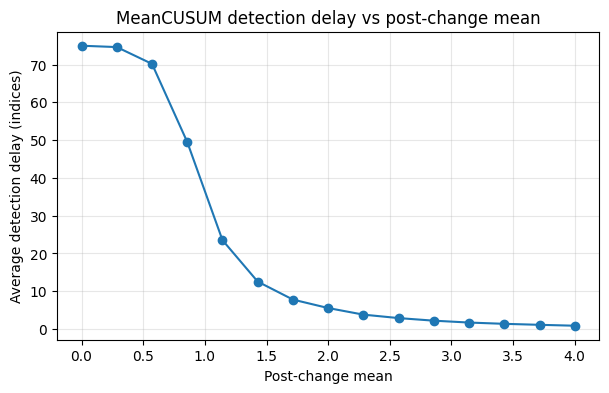

In [18]:
plt.figure(figsize=(7, 4))
plt.plot(post_change_mus, mean_delays, marker="o")
plt.xlabel("Post-change mean")
plt.ylabel("Average detection delay (indices)")
plt.title("MeanCUSUM detection delay vs post-change mean")
plt.grid(alpha=0.3)
plt.show()

## Notes for collaborators

- Internal detector counters often represent sample size (`t=1,2,...`).
- Public Monte Carlo outputs (for example `mc_alarm_times`) use 0-indexed indices.
- `changepoint` can be an `int` or a callable `f(rng, stream_len, path_idx) -> int`;
  if path-specific behavior is not needed, ignore `path_idx`.